# Demand-side EDA — DA buy-offer shift at March 2025 is a regulatory change (Rule 28.8), not behavioral

nb03–nb09 analyzed supply-side bidding exclusively. The demand side (`buy_sell='C'`) was never touched — ~27% of DA offer activity, ~24% of active units in 2024+.

**Key finding up front** (to spare the reader suspense): the dramatic March 2025 shift in DA buy-offer volumes that jumps out of the aggregate data **is not a behavioral response to MTU15-IDA and is not a format artefact**. It is the **elimination of Rule 28.8** — the obligation that required participants with bilateral contracts to submit DA buy offers at opportunity cost. CNMC eliminated this rule at the March 2025 reform because 2024's prolonged negative-price episodes made the mechanism perverse.

Source: `docs/regulation/spain/20250228_cnmc_mtu15.pdf` (BOE Resolución 4908, CNMC 28-Feb-2025), Section F "Otras cuestiones — Ofertas a coste de oportunidad (Regla 28.8)".

This notebook documents what the pre- and post-reform DA buy-offer data actually represents, explains why naive pre/post comparison is misleading, and lays out the clean pathways for actually studying demand-side reform behavior.


## § 0 — Setup

In [1]:
import warnings, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import duckdb
from mtu.notebook_utils import (
    PROJECT_ROOT,
    IDA_REFORM, ISP15_REFORM, INTRADAY_REFORM, DAY_AHEAD_REFORM,
)

warnings.filterwarnings('ignore', category=RuntimeWarning)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

CAB = PROJECT_ROOT / 'data/processed/omie/mercado_diario/ofertas/cab_all.parquet'
DET = PROJECT_ROOT / 'data/processed/omie/mercado_diario/ofertas/det_all.parquet'
LU_PATH = PROJECT_ROOT / 'data/external/omie_reference/lista_unidades.csv'

con = duckdb.connect()
con.execute("SET memory_limit='6GB'")
con.execute('SET threads=4')
con.execute('SET preserve_insertion_order=false')

FIRMS = {
    'ENDESA':        ['ENDESA'],
    'IBERDROLA':     ['IBERDROLA', 'CURENERGÍA'],
    'NATURGY':       ['GAS NATURAL', 'NATURGY'],
    'EDP':           ['EDP'],
    'TOTALENERGIES': ['TOTALENERGIES'],
    'REPSOL':        ['REPSOL'],
    'ACCIONA':       ['ACCIONA'],
    'SHELL':         ['SHELL'],
    'AXPO':          ['AXPO'],
    'FORTIA':        ['FORTIA'],
}
def map_firm(owner):
    if pd.isna(owner): return 'OTHER'
    s = str(owner).upper()
    for firm, kws in FIRMS.items():
        for kw in kws:
            if kw in s: return firm
    return 'OTHER'

lu = pd.read_csv(LU_PATH)
lu['firm_group'] = lu['owner_agent'].apply(map_firm)
firm_map = lu[['unit_code','firm_group','unit_type','technology','owner_agent']].drop_duplicates('unit_code')
firm_map.to_parquet('/tmp/nb10_firm_map.parquet', index=False)

print(f'lista_unidades rows: {len(lu):,}')
print('firm_group distribution:')
print(lu['firm_group'].value_counts().to_string())
print()
print(f'Reforms: IDA={IDA_REFORM.date()}, ISP15={ISP15_REFORM.date()}, '
      f'MTU15-IDA={INTRADAY_REFORM.date()}, MTU15-DA={DAY_AHEAD_REFORM.date()}')

lista_unidades rows: 3,950
firm_group distribution:
firm_group
OTHER            3144
AXPO              316
IBERDROLA         123
REPSOL             63
NATURGY            56
EDP                54
ENDESA             54
SHELL              54
ACCIONA            53
TOTALENERGIES      28
FORTIA              5

Reforms: IDA=2024-06-14, ISP15=2024-12-01, MTU15-IDA=2025-03-19, MTU15-DA=2025-10-01


## § 1 — Demand-side market structure (2024-2026)

Who actually buys on the DA side? Before interpreting volumes, see the firm-group / unit-type composition.

In [2]:
# §1 — Market structure
q1 = (
    "WITH cab_buy AS (SELECT CAST(date AS DATE) AS date, offer_code, version, unit_code "
    f"                 FROM read_parquet('{CAB}') WHERE buy_sell='C' "
    "                   AND CAST(date AS DATE) >= DATE '2024-01-01'), "
    "det_agg AS (SELECT CAST(date AS DATE) AS date, offer_code, version, SUM(quantity_mw) AS total_mw "
    f"            FROM read_parquet('{DET}') WHERE CAST(date AS DATE) >= DATE '2024-01-01' "
    "            GROUP BY 1,2,3) "
    "SELECT f.firm_group, f.unit_type, COUNT(DISTINCT c.unit_code) AS n_units, "
    "       COUNT(*) AS n_offer_periods, SUM(d.total_mw) AS sum_mwh "
    "FROM cab_buy c JOIN det_agg d USING (date, offer_code, version) "
    "JOIN read_parquet('/tmp/nb10_firm_map.parquet') f ON f.unit_code=c.unit_code "
    "GROUP BY 1,2 ORDER BY sum_mwh DESC"
)
struct = con.execute(q1).fetchdf()
print('§1 · Top 15 firm-group × unit-type combos by DA buy volume (2024-2026):')
print(struct.head(15).round(0).to_string(index=False))

print('\n§1 · Firm-group totals:')
agg = (struct.groupby('firm_group')
             .agg(n_units=('n_units','sum'), n_op=('n_offer_periods','sum'), sum_mwh=('sum_mwh','sum'))
             .sort_values('sum_mwh', ascending=False))
print(agg.round(0).to_string())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

§1 · Top 15 firm-group × unit-type combos by DA buy volume (2024-2026):
   firm_group                      unit_type  n_units  n_offer_periods     sum_mwh
        OTHER                COMERCIALIZADOR      391           218255 733308997.0
        OTHER             CONSUMIDOR DIRECTO      116            75325 215985810.0
       ENDESA                COMERCIALIZADOR        5             3200  90149941.0
TOTALENERGIES                COMERCIALIZADOR        4             2160  64111199.0
      ACCIONA                COMERCIALIZADOR        4             2960  42380991.0
    IBERDROLA                         BOMBEO        5             3591  36848950.0
          EDP                       GENERICA        1              644  36670964.0
    IBERDROLA                COMERCIALIZADOR        6             3082  32066308.0
         AXPO                COMERCIALIZADOR        5             2930  30130402.0
          EDP                         BOMBEO        6             4227  26906092.0
       FORTIA  

## § 2 — Monthly DA buy volume by firm-group

Trajectory across 2024-2026. The March 2025 cliff is visible immediately — OTHER collapses, named retailers shift.

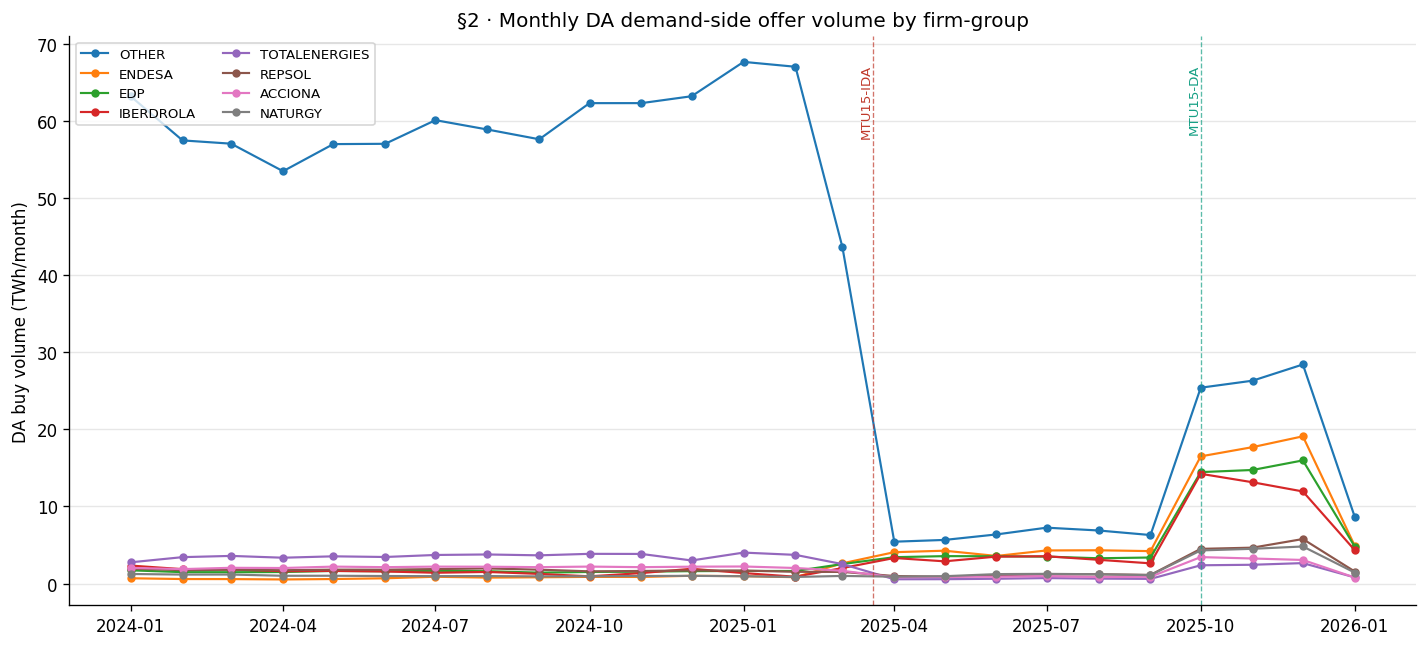

§2 · Monthly DA buy volume (GWh), top firm-groups:
firm_group  OTHER  ENDESA    EDP  IBERDROLA  TOTALENERGIES  REPSOL  ACCIONA  NATURGY
mon                                                                                 
2024-01     63180     686   1713       2331           2754    1923     2029     1240
2024-02     57463     584   1480       1865           3424    1741     1873     1164
2024-03     57039     578   1469       1822           3585    1792     2043     1169
2024-04     53469     531   1497       1604           3349    1728     2015     1006
2024-05     56983     586   1634       1642           3530    1805     2196     1010
2024-06     57023     683   1591       1567           3444    1798     2125      975
2024-07     60089     879   1654       1400           3706    1877     2196      958
2024-08     58878     772   1602       1506           3771    1958     2186      972
2024-09     57610     813   1413       1251           3659    1797     2125      927
2024-10     62

In [3]:
# §2 — Monthly DA buy volume by firm-group
q2 = (
    "WITH cab_buy AS (SELECT CAST(date AS DATE) AS date, offer_code, version, unit_code "
    f"                 FROM read_parquet('{CAB}') WHERE buy_sell='C' "
    "                   AND CAST(date AS DATE) >= DATE '2024-01-01'), "
    "det_agg AS (SELECT CAST(date AS DATE) AS date, offer_code, version, SUM(quantity_mw) AS total_mw "
    f"            FROM read_parquet('{DET}') WHERE CAST(date AS DATE) >= DATE '2024-01-01' "
    "            GROUP BY 1,2,3) "
    "SELECT DATE_TRUNC('month', c.date) AS mon, f.firm_group, SUM(d.total_mw) AS sum_mwh "
    "FROM cab_buy c JOIN det_agg d USING (date, offer_code, version) "
    "JOIN read_parquet('/tmp/nb10_firm_map.parquet') f ON f.unit_code=c.unit_code "
    "GROUP BY 1,2 ORDER BY 1,2"
)
monthly = con.execute(q2).fetchdf()
monthly['mon'] = pd.to_datetime(monthly['mon'])
piv = monthly.pivot_table(index='mon', columns='firm_group', values='sum_mwh').fillna(0)
top_firms = piv.sum().nlargest(8).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5.5))
for firm in top_firms:
    ax.plot(piv.index, piv[firm] / 1e6, '-o', markersize=4, lw=1.3, label=firm)
for d, col, lbl in [(INTRADAY_REFORM, '#c0392b', 'MTU15-IDA'),
                    (DAY_AHEAD_REFORM, '#16a085', 'MTU15-DA')]:
    ax.axvline(pd.Timestamp(d), color=col, ls='--', lw=0.8, alpha=0.7)
    ax.text(pd.Timestamp(d), ax.get_ylim()[1]*0.95, lbl, rotation=90,
            va='top', ha='right', fontsize=8, color=col)
ax.set_ylabel('DA buy volume (TWh/month)')
ax.set_title('§2 · Monthly DA demand-side offer volume by firm-group')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print('§2 · Monthly DA buy volume (GWh), top firm-groups:')
piv_gwh = (piv[top_firms] / 1e3).round(0).astype(int)
piv_gwh.index = piv_gwh.index.strftime('%Y-%m')
print(piv_gwh.to_string())

## § 3 — Per-unit monthly avg MW per offer-period

The aggregate hides the mechanism. Look at the top individual buyers.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

§3 · Monthly avg MW per offer-period for top buy-side units:
unit_code  EGEDC01  ENDE01 GEDPGC2  GGNCOC1  HCGC01  IGESC2    MUEB  TOTRM01
mon                                                                         
2024-01      802.0   280.0       —    400.0   751.0   500.0   336.0   2201.0
2024-02      802.0   280.0       —    400.0   727.0   500.0   163.0   1920.0
2024-03      802.0   280.0       —    400.0   737.0   500.0    39.0   1825.0
2024-04      825.0   280.0   501.0    400.0   752.0   500.0    27.0   1651.0
2024-05      901.0   280.0   501.0    400.0   756.0   500.0   138.0   1745.0
2024-06      901.0   280.0   501.0    400.0   779.0   500.0   211.0   1784.0
2024-07      901.0   280.0   501.0    400.0   775.0   500.0   339.0   1982.0
2024-08      901.0   280.0   501.0    400.0   686.0   500.0   404.0   2069.0
2024-09      901.0   280.0   501.0    400.0   630.0   500.0   281.0   2081.0
2024-10      901.0   280.0   501.0    400.0   644.0   500.0   160.0   2172.0
2024-11      90

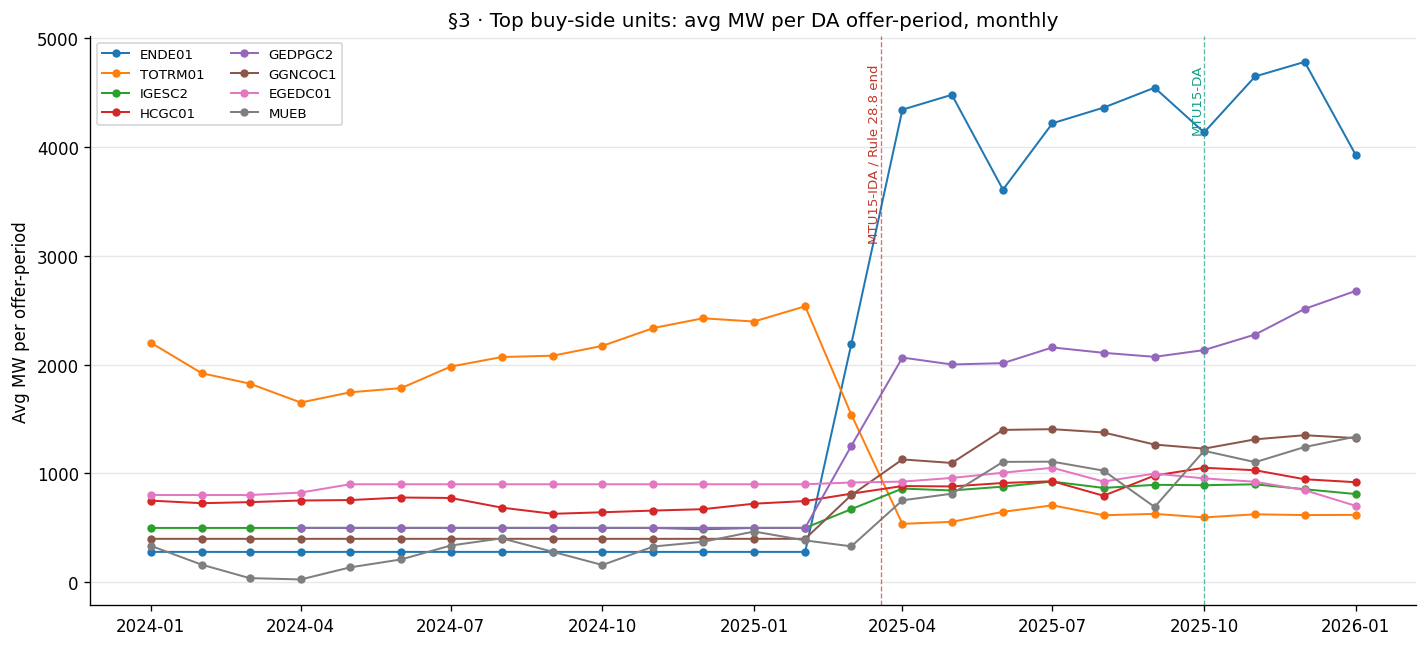

In [4]:
# §3 — Per-unit monthly trajectory
TOP_UNITS = ['ENDE01','TOTRM01','IGESC2','HCGC01','GEDPGC2','GGNCOC1','EGEDC01','MUEB']
top_list = "'" + "','".join(TOP_UNITS) + "'"

q3 = (
    "WITH cab_buy AS (SELECT CAST(date AS DATE) AS date, offer_code, version, unit_code "
    f"                 FROM read_parquet('{CAB}') WHERE buy_sell='C' "
    f"                   AND CAST(date AS DATE) >= DATE '2024-01-01' AND unit_code IN ({top_list})), "
    "det_agg AS (SELECT CAST(date AS DATE) AS date, offer_code, version, period, SUM(quantity_mw) AS tot_mw "
    f"            FROM read_parquet('{DET}') WHERE CAST(date AS DATE) >= DATE '2024-01-01' "
    "            GROUP BY 1,2,3,4), "
    "joined AS (SELECT c.unit_code, c.date, d.period, d.tot_mw "
    "           FROM cab_buy c JOIN det_agg d USING (date, offer_code, version)) "
    "SELECT DATE_TRUNC('month', date) AS mon, unit_code, SUM(tot_mw) AS sum_mw, "
    "       COUNT(*) AS n_op, SUM(tot_mw) / NULLIF(COUNT(*), 0) AS avg_mw_per_op "
    "FROM joined GROUP BY 1,2 ORDER BY 2,1"
)
per_unit = con.execute(q3).fetchdf()
per_unit['mon'] = pd.to_datetime(per_unit['mon'])

piv = per_unit.pivot_table(index='mon', columns='unit_code', values='avg_mw_per_op').round(0)
piv.index = piv.index.strftime('%Y-%m')
print('§3 · Monthly avg MW per offer-period for top buy-side units:')
print(piv.fillna('—').to_string())

fig, ax = plt.subplots(figsize=(12, 5.5))
for unit in TOP_UNITS:
    sub = per_unit[per_unit['unit_code']==unit].sort_values('mon')
    ax.plot(sub['mon'], sub['avg_mw_per_op'], '-o', markersize=4, lw=1.2, label=unit)
for d, col, lbl in [(INTRADAY_REFORM, '#c0392b', 'MTU15-IDA / Rule 28.8 end'),
                    (DAY_AHEAD_REFORM, '#16a085', 'MTU15-DA')]:
    ax.axvline(pd.Timestamp(d), color=col, ls='--', lw=0.8, alpha=0.7)
    ax.text(pd.Timestamp(d), ax.get_ylim()[1]*0.95, lbl, rotation=90,
            va='top', ha='right', fontsize=8, color=col)
ax.set_ylabel('Avg MW per offer-period')
ax.set_title('§3 · Top buy-side units: avg MW per DA offer-period, monthly')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## § 4 — Interpretation: Rule 28.8 elimination, not MTU15-IDA behavioral

### What §2 and §3 show

Aggregate DA buy volume: ~70 TWh/month (2024 and early 2025) → ~20 TWh/month (April 2025 onward). A 70% collapse at March 2025.

Per-unit: the largest buyers bid flat rounded quantities every offer-period pre-March-2025 — ENDE01 always 280 MW, IGESC2 always 500 MW, GEDPGC2 always 501 MW, GGNCOC1 always 400 MW, EGEDC01 always 901 MW. Post-March-2025, the same units bid variable realistic retailer-scale quantities (1-4 GW per offer-period).

### The cause is documented

`docs/regulation/spain/20250228_cnmc_mtu15.pdf` (CNMC Resolución 4908, 28-Feb-2025, published 12-Mar-2025), Section F "Otras cuestiones — Ofertas a coste de oportunidad (Regla 28.8)":

> *La revisión de la Regla 28.8 se ha revelado conveniente durante el año 2024, en el que se ha registrado un periodo prolongado de precios negativos por primera vez en la historia del mercado diario. En estas circunstancias, la obligación de presentar oferta de compra por la energía declarada en contratos bilaterales al coste de oportunidad puede entrar en conflicto con la decisión de los participantes en el mercado de mantener la ejecución de sus contratos bilaterales.*

**Rule 28.8 (pre-reform)**: required participants with bilateral contracts to submit DA buy offers at opportunity cost, for their bilateral-contract volumes — an accounting mechanism to cover bilateral-contract energy through the DA market.

**CNMC eliminated the first paragraph of Rule 28.8** at this reform, because 2024's negative-price episodes made the opportunity-cost buy-back obligation conflict with participants' bilateral-contract management and created perverse incentives (particularly for low-flexibility units like nuclear that couldn't easily unwind if a buy-back offer unexpectedly cleared).

### The flat-rounded quantities are the signature

ENDE01 bidding 280 MW every hour for 15 months without variation is not real demand. Real retailer demand has daily load curves, weekly patterns, weather responses. The flat quantities are exactly what programmatic opportunity-cost bid generation would produce: constant quantity = bilateral-contract MW, submitted at the opportunity-cost price, every hour.

When Rule 28.8 was eliminated, these programmatic bids stopped. The remaining post-reform DA buy data is real retailer/consumer demand — variable, load-following, realistic scale (1-4 GW per offer-period for a major retailer like Endesa with ~5M customers).

### This is NOT:
- ...a behavioral shift by retailers in response to MTU15-IDA.
- ...a format artefact (like DA price 0-padding or MAV mandatory→optional).
- ...a strategic-bidding-pattern change.

### This IS:
- A **regulatory change in what DA buy offers are required** to be submitted. CNMC eliminated a rule; the corresponding artificial bids disappeared from the data.
- The **MTU15-IDA date coincided** (both took effect on March 18-19, 2025) but did not *cause* the shift.

### Implications for demand-side analysis

The pre-March-2025 DA buy-offer data is dominated by artificial Rule 28.8 bids. It cannot be used as a proxy for retailer/consumer demand behavior. To study actual demand-side behavior pre/post reforms, we need:

1. **Cleared DA demand** (`pdbc` with buy_sell='C', and/or `pdbce` for firm-level cleared demand). Rule 28.8 was an *offer* requirement; its elimination doesn't mechanically change clearing. Cleared buy volumes should reflect actual retailer demand on both sides of the reform.
2. **IDA buy-side offers**. Rule 28.8 applied to DA only. IDA demand-side offers should be directly comparable pre/post.
3. **Post-March-2025 DA buy-offers only**. Short but structurally clean window for within-post-reform analysis.

### Other concurrent March 2025 changes

The same CNMC resolution introduced multiple simultaneous changes. Any reform-attribution claim for the March 18-19, 2025 date must disentangle:

- Rule 28.8 elimination (what we just diagnosed).
- DA offer-typology change: MIC/MP complex orders → Simple + Scalable Complex Orders (SCOs) + Simple Block + Exclusive Group of Blocks. Affects both buy and sell sides.
- MTU15-IDA continuous intraday (15-min delivery products).
- Second Auction elimination (Jan 29, 2025, concurrent).
- DA file format changes (price 0-padding, MAV mandatory→optional).

Saved as `MEMORY/ref_rule_28_8_elimination.md` so future researchers have the reference.

### Project-level lesson

This is the first time in the project where **reading the market-rule documentation has directly resolved an empirical puzzle**. We now have three documented pre-March-2025 DA-data contaminations: price 0-padding, MAV mandatory-default, Rule 28.8 opportunity-cost bids. All must be accounted for in any DA-based reform analysis. For the thesis, this pattern of documentation-first diagnosis is the right methodology.

### What nb10 should do next (if demand-side analysis is pursued)

1. Work with cleared demand (`pdbc`/`pdbce`) rather than offered demand for pre/post comparison.
2. Examine IDA buy-side offers — not contaminated by Rule 28.8.
3. Use post-March-2025 window only for DA-offer-based analysis.

This is the honest next step for the demand-side thread.
